In [1]:
# 기본 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

'''
[Step 1] 데이터 준비 - read_csv() 함수로 자동차 연비 데이터셋 가져오기
'''
# CSV 파일을 데이터프레임으로 변환
df = pd.read_csv('./data/auto-mpg.csv', header=None)

# 열 이름 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name'] 

# 데이터 살펴보기
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [2]:
'''
[Step 2] 데이터 탐색
'''

# 데이터 자료형 확인
df.info()

# 숫자형 데이터로 채워져있을 horsepower Dtype가 object가 되어있다.
# 이상치가 있다는 말이니 찾아보고 그걸 어떻게 처리할지 정해보자.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [3]:
# 데이터 통계 요약정보 확인
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [4]:
# 결측치 확인
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
name            0
dtype: int64

In [5]:
# 중복 데이터 확인
df.duplicated().sum()

np.int64(0)

In [6]:
# 결측치는 아니지만 데이터 타입이 일치하지 않은 데이터들을 찾아서 na로 변경 - 일괄 처리를 위해서
# horsepower
df.loc[100,'horsepower'] ='<<' # '?' 이외의 일치하지않는 데이터 임의로 추가

In [7]:
# 방법 1
# df.horsepower.astype(float) -> horsepower의 데이터 타입을 실수로 변환하겠다는 말
# 이걸로 오류 문구가 뜨는 애들을 수시로 수정하기
# 이걸 자동화하는 방법 try 명령어 활용

# gpt와 강사님 트라이한 코드 참고해서 나온 코드

# 빈 리스트에 변환 불가 값 저장
bad_values = []

# 각 값마다 float 변환 시도
for val in df['horsepower']:
    try:
        float(val)
    except Exception as e:
        bad_values.append(val)  # 에러 발생 값 저장

# 에러 난 값들을 NaN으로 대체
df['horsepower'] = df['horsepower'].replace(bad_values, pd.NA)

In [8]:
# 방법 2
df.horsepower = pd.to_numeric(df.horsepower,errors='coerce')

In [9]:
# 방법 3
df.horsepower = df.horsepower.apply(lambda x : x if isinstance(x,float) else pd.NA)

In [10]:
# 결측치 데이터 처리방안
# 1. 결측치가 있는 데이터의 행들을 전부 출력
# 학생풀이 -> 이건 데이터 처리하기이전에 출력가능하게 한거..
for idx, val in enumerate(df['horsepower']):
    try:
        float(val)
    except Exception:
        display(df.iloc[[idx]]) 
    # except Exception as e:
    #    print(df.iloc[idx])

In [11]:
# 강사 풀이
df[df.horsepower.isna()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,name
32,25.0,4,98.0,NaN,2046.0,19.0,71,1,ford pinto
100,18.0,6,250.0,NaN,3021.0,16.5,73,1,ford maverick
126,21.0,6,200.0,NaN,2875.0,17.0,74,1,ford maverick
330,40.9,4,85.0,NaN,1835.0,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,NaN,2905.0,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,NaN,2320.0,15.8,81,2,renault 18i
374,23.0,4,151.0,NaN,3035.0,20.5,82,1,amc concord dl


In [12]:
# 결측치는 제거
df.dropna()
# 정확도나 관계성을 조금이라도 늘리기위해 결측치를 삭제하지않는 경우
# 결측치를 삭제하지않고 결측치(NaN)를 제외한 데이터만 선택하는 코드를 작성
# df[~df.horsepower.isna()]

# 결측치를 제거하면 index가 중간중간 비어있기 때문에 재정렬 reset
df.reset_index()

,index,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,name
0,0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...,...
393,393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


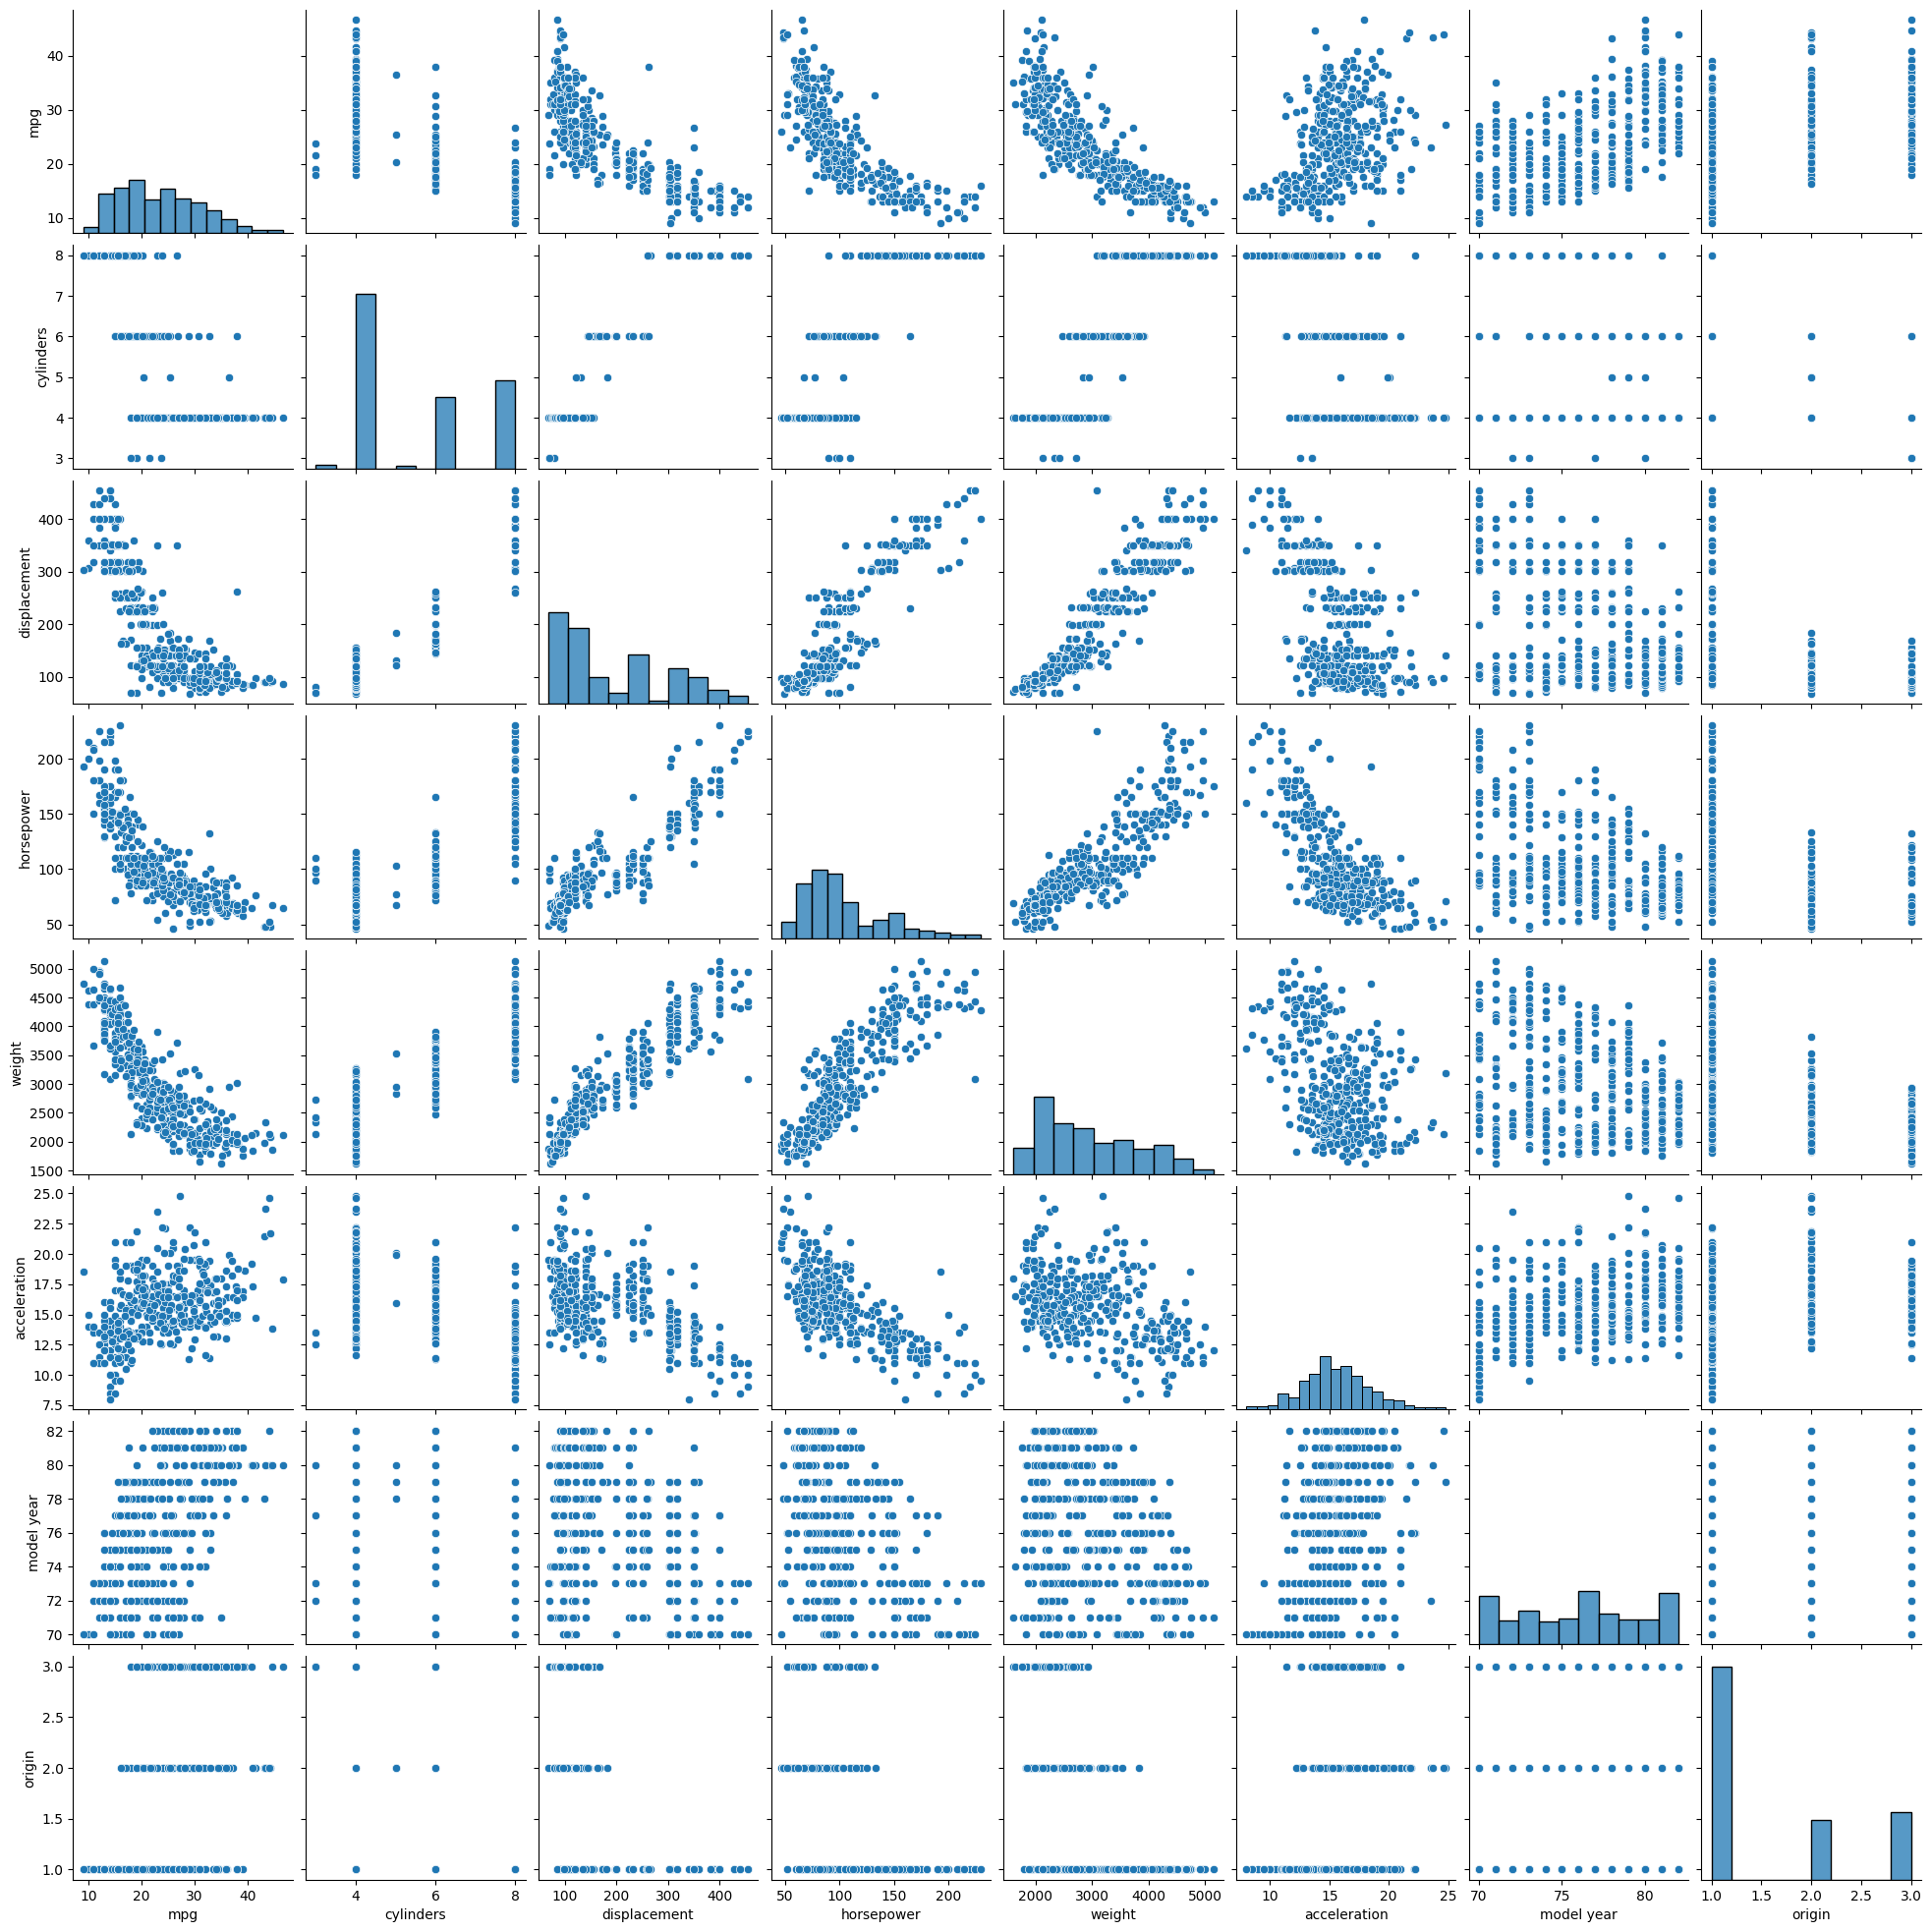

In [13]:
# seaborn pairplot 산점도
sns.pairplot(df)

In [14]:
# 상관계수 분석 - 데이터프레임2
# 본인은 1.0, 주어진수와 자신과의 상관도를 나타내는 수치니깐 최대치 1.0이 나온다.
corr = df.corr(numeric_only=True)
corr

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
mpg,1.000000,-0.775396,-0.804203,-0.779862,-0.831741,0.420289,0.579267,0.563450
cylinders,-0.775396,1.000000,0.950721,0.843625,0.896017,-0.505419,-0.348746,-0.562543
displacement,-0.804203,0.950721,1.000000,0.898376,0.932824,-0.543684,-0.370164,-0.609409
horsepower,-0.779862,0.843625,0.898376,1.000000,0.864800,-0.689083,-0.417697,-0.456364
weight,-0.831741,0.896017,0.932824,0.864800,1.000000,-0.417457,-0.306564,-0.581024
acceleration,0.420289,-0.505419,-0.543684,-0.689083,-0.417457,1.000000,0.288137,0.205873
model year,0.579267,-0.348746,-0.370164,-0.417697,-0.306564,0.288137,1.000000,0.180662
origin,0.563450,-0.562543,-0.609409,-0.456364,-0.581024,0.205873,0.180662,1.000000


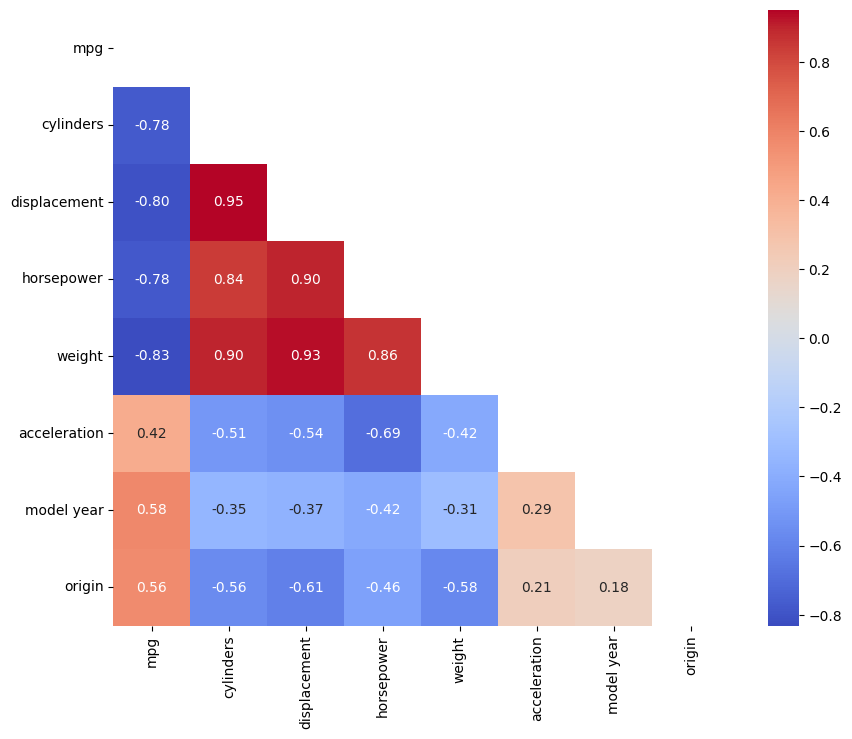

In [15]:
# 상관계수 분석 - 히트맵
mask = np.triu(np.ones_like(corr, dtype=bool))   # 마스크 생성 (상단 트라이앵글을 숨김)

# 히트맵 그리기 - 1.0 중간 선을 기준으로 아래 쪽을 마스크로 그래프 범위지정하고 표현
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, cmap='coolwarm', 
            annot=True, fmt=".2f", cbar=True, square=True)
plt.show()

In [16]:
'''
[Step 3] 데이터 전처리
'''

# horsepower 열의 고유값 확인
df['horsepower'].unique()          

array([130., 165., 150., 140., 198., 220., 215., 225., 190., 170., 160.,
        95.,  97.,  85.,  88.,  46.,  87.,  90., 113., 200., 210., 193.,
        nan, 100., 105., 175., 153., 180., 110.,  72.,  86.,  70.,  76.,
        65.,  69.,  60.,  80.,  54., 208., 155., 112.,  92., 145., 137.,
       158., 167.,  94., 107., 230.,  49.,  75.,  91., 122.,  67.,  83.,
        78.,  52.,  61.,  93., 148., 129.,  96.,  71.,  98., 115.,  53.,
        81.,  79., 120., 152., 102., 108.,  68.,  58., 149.,  89.,  63.,
        48.,  66., 139., 103., 125., 133., 138., 135., 142.,  77.,  62.,
       132.,  84.,  64.,  74., 116.,  82.])

In [17]:
# horsepower 열의 자료형 변경 (문자열 ->숫자)

df['horsepower'] = df['horsepower'].replace('?', np.nan)      # '?'을 np.nan으로 변경
df['horsepower'] = df['horsepower'].astype('float')           # 문자열을 실수형으로 변환

df.describe()                                   

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,391.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.511509,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.531429,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,94.000000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,127.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [18]:
# 결측치 제거
print(df['horsepower'].isnull().sum())
df_nan = df.dropna(subset=['horsepower'], axis=0)                 
print(df_nan['horsepower'].isnull().sum())

7
0


In [19]:
# 결측치 대체
print(df['horsepower'].isnull().sum())
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())               
print(df['horsepower'].isnull().sum())

7
0


In [20]:
# 상관계수 분석 - 데이터프레임
corr = df.corr(numeric_only=True)
corr

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
mpg,1.000000,-0.775396,-0.804203,-0.772377,-0.831741,0.420289,0.579267,0.563450
cylinders,-0.775396,1.000000,0.950721,0.839474,0.896017,-0.505419,-0.348746,-0.562543
displacement,-0.804203,0.950721,1.000000,0.894437,0.932824,-0.543684,-0.370164,-0.609409
horsepower,-0.772377,0.839474,0.894437,1.000000,0.860832,-0.684041,-0.412625,-0.454559
weight,-0.831741,0.896017,0.932824,0.860832,1.000000,-0.417457,-0.306564,-0.581024
acceleration,0.420289,-0.505419,-0.543684,-0.684041,-0.417457,1.000000,0.288137,0.205873
model year,0.579267,-0.348746,-0.370164,-0.412625,-0.306564,0.288137,1.000000,0.180662
origin,0.563450,-0.562543,-0.609409,-0.454559,-0.581024,0.205873,0.180662,1.000000


In [21]:
# 수치형 데이터 선택
df.describe().columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin'],
      dtype='object')

In [22]:
'''
[Step 3] 속성(feature 또는 variable) 선택
'''

# 분석에 활용할 열(속성)을 선택 (연비, 실린더, 출력, 중량)
ndf = df[['mpg', 'cylinders', 'horsepower', 'weight']]
ndf.head() 

,mpg,cylinders,horsepower,weight
0,18.0,8,130.0,3504.0
1,15.0,8,165.0,3693.0
2,18.0,8,150.0,3436.0
3,16.0,8,150.0,3433.0
4,17.0,8,140.0,3449.0


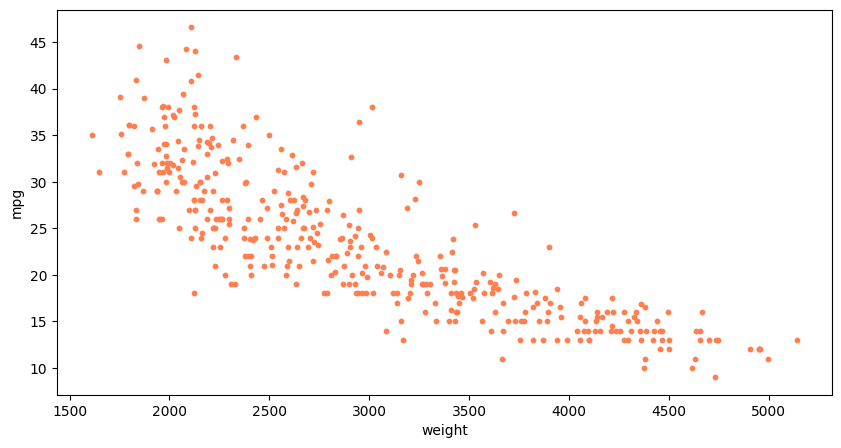

In [23]:
### 종속 변수 Y인 "연비(mpg)"와 다른 변수 간의 선형관계를 그래프(산점도)로 확인
# Matplotlib으로 산점도 그리기
ndf.plot(kind='scatter', x='weight', y='mpg',  c='coral', s=10, figsize=(10, 5))
plt.show()

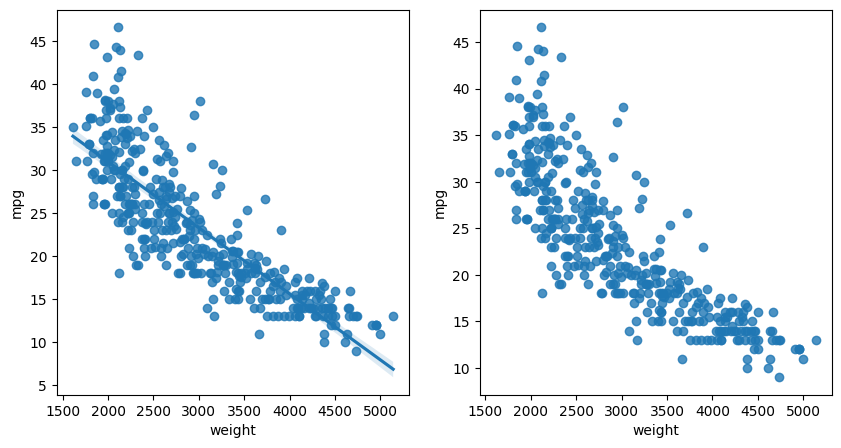

In [24]:
# seaborn으로 산점도 그리기
fig = plt.figure(figsize=(10, 5))   
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
sns.regplot(x='weight', y='mpg', data=ndf, ax=ax1)                 # 회귀선 표시
sns.regplot(x='weight', y='mpg', data=ndf, ax=ax2, fit_reg=False)  # 회귀선 미표시
plt.show()

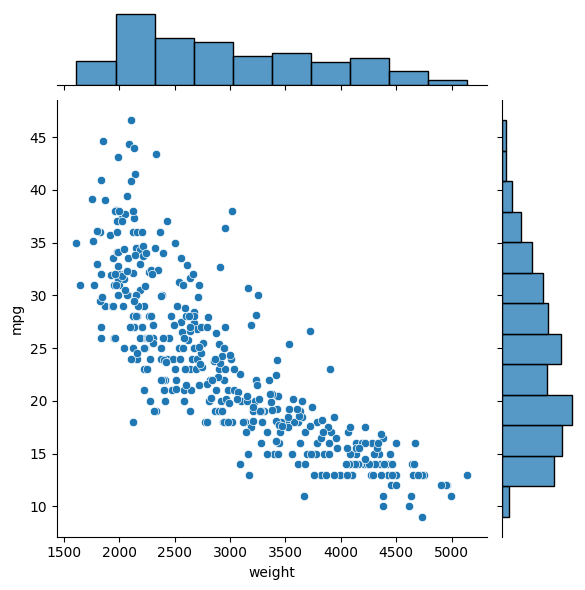

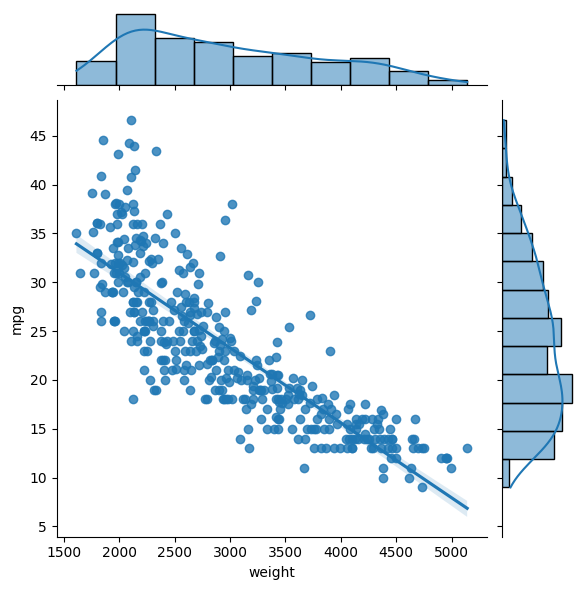

In [25]:
# seaborn 조인트 그래프 - 산점도, 히스토그램
sns.jointplot(x='weight', y='mpg', data=ndf);             # 회귀선 없음
sns.jointplot(x='weight', y='mpg', kind='reg', data=ndf);  # 회귀선 표시

In [26]:
'''
Step 4: 데이터셋 구분 - 훈련용(train data)/ 검증용(test data)
'''

# 속성(변수) 선택
X=ndf[['weight']]  # 독립 변수 X ^ [[]]한 이유
y=ndf['mpg']       # 종속 변수 y : X에 따라서 y의 값이 바뀌기 때문에 종속 변수

# train data 와 test data로 구분(7:3 비율)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,               # 독립 변수 
                                                    y,               # 종속 변수
                                                    test_size=0.3,   # 검증 30%
                                                    # train_size = 0.7, 동일 저절로 지정
                                                    random_state=10) # 랜덤 추출 값 

print('train data 개수: ', len(X_train))
print('test data 개수: ', len(X_test))
print('total data 개수:', len(X))

train data 개수:  278
test data 개수:  120
total data 개수: 398


In [27]:
'''
Step 5: 단순회귀분석 모델 - sklearn 사용
'''

# sklearn 라이브러리에서 선형회귀분석 모듈 가져오기
from sklearn.linear_model import LinearRegression

# 단순회귀분석 모델 객체 생성
lr = LinearRegression()   

# train data를 가지고 모델 학습
lr.fit(X_train, y_train)

# 학습을 마친 모델에 test data를 적용하여 결정계수(R-제곱) 계산
r_square = lr.score(X_test, y_test)
print('R^2 결정계수: ', r_square)

R^2 결정계수:  0.689363809315209


In [28]:
# 학생들의 시험점수를 예측
# 1. 참고할 정보가 없다면, 모든 학생이 평균점수를 받을 거라고 예측
# 2. 실제는 평균보다 높거나 낮다. 그래서 오차가 발생, 결정계수의 기준선은 평균이 된다.
# R² 기준선 → “평균만 알고 있는 모델”의 오차가 기준점
# R² = 1−(평균 예측 오차 제곱합) / (선형모델 오차 제곱합​)

# 선형모델의 예측
# 정보 : 공부시간 추가정보 가 있으면 공부시간, 시험점수의 관계를 선형회귀 모델로 만듦
# 결정계수가 0 이면 그냥 평균을 출력하는 의미

# 평균 오차와 실제 모델이 낸 오차를 비교한다.

In [29]:
# 회귀식의 기울기
print('기울기 a: ', lr.coef_)

# 회귀식의 y절편
print('y절편 b', lr.intercept_)

기울기 a:  [-0.0076554]
y절편 b 46.60365052224634


In [30]:
# 모델에 test data 데이터를 입력하여 예측한 값 y_hat을 실제 값 y와 비교 
y_hat = lr.predict(X_test)

# 오차 계산
# y_test가 정답, y_hat은 추론하여 나온 값 : 모델오차 제곱값 계산
test_preds = pd.DataFrame(y_test)
test_preds.columns = ['y_test']
test_preds['y_hat'] = y_hat
test_preds['squared_error'] = (test_preds['y_hat'] - test_preds['y_test'])**2 # 음수 없애기 위해 제곱
test_preds

,y_test,y_hat,squared_error
331,33.8,30.182824,13.083965
111,18.0,30.343587,152.364137
350,34.7,29.646946,25.533357
205,28.0,30.106270,4.436372
56,26.0,31.637349,31.779704
...,...,...,...
17,21.0,26.799138,33.630001
225,17.5,19.656652,4.651150
223,15.5,14.910306,0.347739
59,23.0,29.348385,40.301995


In [31]:
# 평균 제곱 오차
mse = test_preds['squared_error'].mean()
print('mse: ', mse)

mse:  17.898336128759958


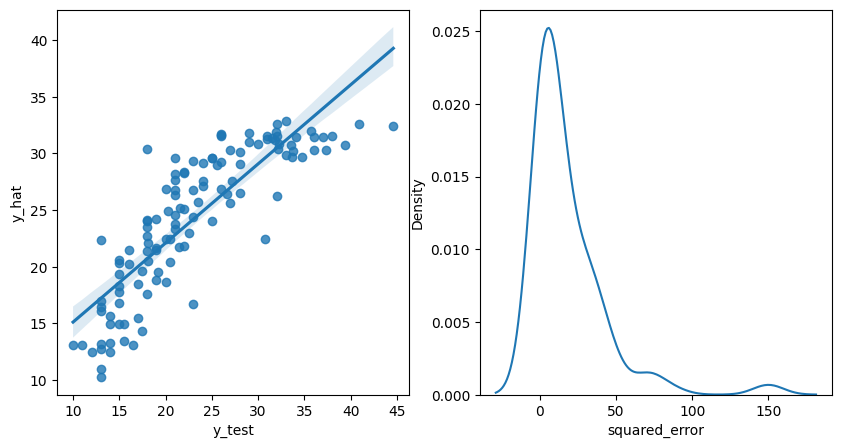

In [32]:
# 오차 분석
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.regplot(x='y_test', y='y_hat',  data=test_preds, ax=axes[0]);  
sns.kdeplot(x='squared_error',  data=test_preds, ax=axes[1]); 

In [33]:
# y_bar : 모든 y값의 평균
# y_hat : 모데링이 예측한 i번째 데이터의 값(예측)
# yi : i번째 데이터의 정답
# 결정계수 : 1 - SSR / SST
# SSR : 잔차 제곱합 sum((yi - y_hat)**2)  값이 작을수록 모델이 정확 (모델이 설명하지 못한 변동량)
# SST : 총 제곱합 sum((yi - y_bar)**2) 단순 평균값으로 데이터의 흩어진 정도를 표현 (데이터의 총 변동량)
# 1 - SSR / SST 에서 오파비율을 뺀 값 --> 모델이 설명해낸 변동성의 비율
# 결정계수가 0.85, 85 예측이고 나머지 15는 예측 못한 수치 표시

In [34]:
# 선형회귀는 단순히 MSE, MSA로 평가를 하면, 어느정도 좋은 모델인지 알수가 없다?
# 결정계수를 통해서 확률로 알 수 있다.

In [35]:
# 결측치를 제거했을 때와 대처했을 때의 수치를 비교
# 독립변수를 weight 가 아닌 다른 요소로 했을 떄 모델의 성능을 측정
# 정답과 선형관계가 뚜렷하거나 선형관계가 있다고 판단되는 변수를 선정
# 학습용 / 테스트용 데이터를 8:2 로 분류
# 결정계수와 MSE 두개 출력
# 예제처럼 오차 분석(시각화)

In [36]:
# 강사 풀이 : nan을 
# 기본 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

'''
[Step 1] 데이터 준비 - read_csv() 함수로 자동차 연비 데이터셋 가져오기
'''
# CSV 파일을 데이터프레임으로 변환
df = pd.read_csv('./data/auto-mpg.csv', header=None)
# 열 이름 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name'] 

# horsepower의 이상치를 nan으로 변환
df.horsepower = pd.to_numeric(df.horsepower, errors='coerce')

# mpg와 선형성이 있는 컬럼들을 상관계수로 확인하기
numeric_cols = df.describe().columns
df.loc[:,numeric_cols].corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
mpg,1.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289,0.579267,0.563450
cylinders,-0.775396,1.000000,0.950721,0.842983,0.896017,-0.505419,-0.348746,-0.562543
displacement,-0.804203,0.950721,1.000000,0.897257,0.932824,-0.543684,-0.370164,-0.609409
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.831741,0.896017,0.932824,0.864538,1.000000,-0.417457,-0.306564,-0.581024
acceleration,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000,0.288137,0.205873
model year,0.579267,-0.348746,-0.370164,-0.416361,-0.306564,0.288137,1.000000,0.180662
origin,0.563450,-0.562543,-0.609409,-0.455171,-0.581024,0.205873,0.180662,1.000000


In [37]:
# 학습용과 테스트용 데이터를 분리
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df[['displacement']],df.mpg, test_size=0.2,random_state=45)
len(X_train),len(y_train), len(X_test), len(y_test)

(318, 318, 80, 80)

In [38]:
# 학습 선형 회귀
from sklearn.linear_model import LinearRegression
lr = LinearRegression() # 모델 생성
lr.fit(X_train, y_train) # 모델을 학습용 데이터로 학습

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
# 결정 계수
lr.score(X_test,y_test)

0.6540122078670478

<Axes: xlabel='mpg', ylabel='displacement'>

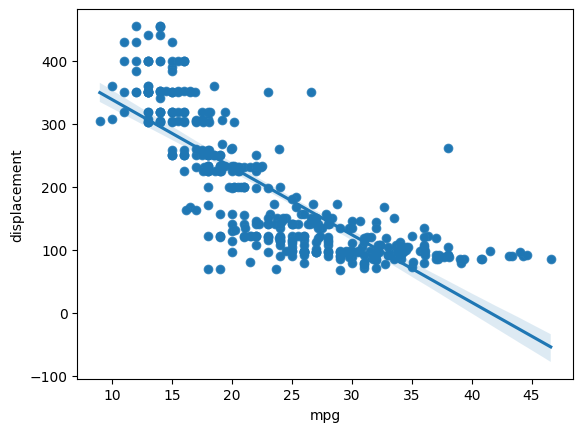

In [40]:
# mpg 와 선형성이 있는 컬럼들을 확인
# 상관계수 , 시각화(산점도), regplot
numeric_cols = df.describe().columns
df.loc[:,numeric_cols].corr()
sns.scatterplot(data=df, x='mpg', y='displacement')
sns.regplot(data=df, x='mpg', y='displacement')

In [41]:
# 강사 풀이 : nan행 제거
# 기본 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

'''
[Step 1] 데이터 준비 - read_csv() 함수로 자동차 연비 데이터셋 가져오기
'''
# CSV 파일을 데이터프레임으로 변환
df = pd.read_csv('./data/auto-mpg.csv', header=None)
# 열 이름 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name'] 

# horsepower의 '?'를 nan으로 변환
df.horsepower = pd.to_numeric(df.horsepower, errors='coerce')

# 결측치 제거
df = df.dropna(subset=['horsepower'], axis=0)

# 학습용과 테스트용 데이터를 분리
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df[['displacement']],df.mpg, test_size=0.2,random_state=45)
len(X_train),len(y_train), len(X_test), len(y_test)

# 학습 선형 회귀
from sklearn.linear_model import LinearRegression
lr = LinearRegression() # 모델 생성
lr.fit(X_train, y_train) # 모델을 학습용 데이터로 학습

# 결정 계수
lr.score(X_test,y_test)

0.6592316739574486

#### 상관계수로 대체한 경우
0.6540122078670478

#### 결측치를 제거한경우
0.6592316739574486

이번 AI학습 활동에서는
결측치를 뭔가로 대체하여 채우기보다는 원본그자체를 살리되 결측치를 제거하는 방향이 더 정확도가 높다는 것을 알 수 있다.

In [42]:
# 학생 풀이
# 결측치를 대체한 경우
# weight가 아닌 다른 요소 horsepower로 선정
# 학습 데이터 : 테스트 데이터 = 8 : 2           

# 기본 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

'''
[Step 1] 데이터 준비 - read_csv() 함수로 자동차 연비 데이터셋 가져오기
'''
# CSV 파일을 데이터프레임으로 변환
df = pd.read_csv('./data/auto-mpg.csv', header=None)
# 열 이름 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name'] 

# horsepower의 이상치를 nan으로 변환
df.horsepower = pd.to_numeric(df.horsepower, errors='coerce')

# 결측치nan을 중간값으로 대체
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())           

# 분석에 활용할 열(속성)을 선택 (연비, 실린더, 출력, 중량)
ndf = df[['mpg', 'cylinders', 'horsepower', 'weight']]
ndf.head() 

# 속성(변수) 선택
X=ndf[['horsepower']]
y=ndf['mpg']

# 인공지능 학습전 설정
# train data 와 test data로 구분(8:2 비율)
# train_test_split()은 데이터를 학습용과 테스트용으로 나누는 함수사용
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,               # 독립 변수 
                                                    y,               # 종속 변수
                                                    train_size = 0.8, # 학습 데이터 80%
                                                    random_state=10) # 랜덤 추출 값

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

# 선형회귀 모델 생성
lr = LinearRegression()

# 학습용 데이터로 모델 학습
lr.fit(X_train, y_train)

# 학습 데이터 예측
y_train_pred = lr.predict(X_train)
# 테스트 데이터 예측
y_test_pred = lr.predict(X_test)

# 결정 계수
lr.score(X_test,y_test)

0.5757145078476782

In [43]:
x_train[['weight']]

NameError: name 'x_train' is not defined

In [ ]:
# 데이터 정규화 또는 스케일링, 이상치 여부 확인하고 제거
# 정규화 : Min-Max Scaling 데이터를 0~1사이의 값으로 압축
# 표준화 : StandardScaler : 데이터를 평균 0, 표준편차 1
# 이상치 제거
# 구간화 : 범주형 데이터로 변환

In [ ]:
from sklearn.preprocessing import StandardScaler
sds = StandardScaler()
x_scaled_train = sds.fit_transform(x_train[['weight']])
x_scaled_test = sds.transform(x_test[['weight']])
len(x_scaled_train),len(x_scaled_test)

(313, 79)

In [ ]:
x_scaled_train

array([[-6.75525278e-01],
       [-9.59886844e-01],
       [-4.03012111e-01],
       [-9.83583641e-01],
       [-4.26708908e-01],
       [-1.16960350e+00],
       [ 1.65742440e+00],
       [ 2.40355932e-01],
       [ 1.09581031e+00],
       [ 4.13028361e-02],
       [-3.49694317e-01],
       [ 5.66186893e-01],
       [-3.35476239e-01],
       [-6.41479113e-02],
       [-3.74575954e-01],
       [-9.61071684e-01],
       [-9.89507840e-01],
       [-8.63914815e-01],
       [ 1.35647508e+00],
       [-1.05467403e+00],
       [-7.90454744e-01],
       [-5.52301933e-01],
       [ 7.79458067e-01],
       [-8.61545135e-01],
       [-1.14946122e+00],
       [-6.48273961e-01],
       [ 2.17843975e-01],
       [ 5.56708174e-01],
       [ 3.65948957e-01],
       [-2.78603926e-01],
       [-6.48273961e-01],
       [-5.51117093e-01],
       [-8.54436096e-01],
       [ 9.73771804e-01],
       [-5.39268694e-01],
       [-1.44717022e-01],
       [ 5.73295932e-01],
       [-4.85950901e-01],
       [ 2.4

In [ ]:
# sklearn 계열의 데이터는 항상 2차원을 요구  demesion 2  
# 학습 선형회귀
from sklearn.linear_model import LinearRegression
lr = LinearRegression()  # 모델생성
lr.fit(x_scaled_train,y_train)  #모델을 학습용 데이터로 학습
# 결정계수
lr.score(x_scaled_test,y_test)

-0.007291854131936892